# National Renewable — historical-only 15-minute baselines

End-to-end pipeline for the Chinese State Grid solar stations:

1. load and physically clean the raw station data;
2. fit missing-value statistics on the training period only;
3. use observations available at forecast origin $t$ to predict active power at $t+15$ min;
4. compare persistence, XGBoost and the repo's vanilla Transformer;
5. score every 15-minute target within each site-month using $1-MAE/Cap$ and $1-RMSE/Cap$.

No target-time measured weather is used. This is a deployable historical-only setup, not oracle weather.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make imports work whether Jupyter starts at the repo root or notebook/model.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.national_renewable import (
    prepare_historical_data, make_xgb_historical_table,
    transformer_feature_columns, make_contiguous_frames,
    window_prediction_frame,
)
from src.helper.models import build_model
from src.helper.metrics import monthly_accuracy_15min, mean_monthly_accuracy


## 1. Configuration

Start with site 1 so the complete notebook runs quickly. After validating the pipeline, change `SITES` to `[1, 2, 4, 5, 6, 7, 8]`. Site 3 is excluded from the default multi-site run because the source paper reports a very high irradiance missing/outlier rate.

In [2]:
SEED = 42
SITES = [1]  # later: [1, 2, 4, 5, 6, 7, 8]
TRAIN_END = "2019-10-01"
VAL_END = "2020-01-01"
HORIZON = 1       # one 15-minute step
LOOKBACK = 96     # Transformer sees the preceding 24 hours
DEVICE = "mps"   # Apple Silicon GPU

np.random.seed(SEED)


## 2. Load and clean

Grossly impossible weather readings are made missing; negative irradiance and negative generation are clipped to zero. Weather inputs are imputed using station medians learned from the training period only. The target `cf` is never imputed. Missing timestamps are inserted on the 15-minute grid so lags cannot accidentally jump across a gap.

In [3]:
prepared, imputation_summary = prepare_historical_data(
    sites=SITES, train_end=TRAIN_END, val_end=VAL_END
)

print("prepared shape:", prepared.shape)
print("columns:", prepared.columns.tolist())
display(prepared.groupby(["site", "split"]).size().rename("rows").to_frame())
display(prepared.head())


prepared shape: (70176, 25)
columns: ['ts', 'irr_total', 'dni', 'ghi', 'temp', 'pressure', 'humidity', 'power', 'site', 'capacity', 'cf', 'irr_total_missing', 'dni_missing', 'ghi_missing', 'temp_missing', 'pressure_missing', 'humidity_missing', 'power_missing', 'tod_sin', 'tod_cos', 'doy_sin', 'doy_cos', 'site_1', 'cf_input', 'split']


rows
site split       
1    test   35136
     train  26208
     val     8832

,ts,irr_total,dni,ghi,temp,pressure,humidity,power,site,capacity,...,pressure_missing,humidity_missing,power_missing,tod_sin,tod_cos,doy_sin,doy_cos,site_1,cf_input,split
0,2019-01-01 00:00:00,0.0,0.0,0.0,-11.7,930.5,39.1,0.0,1,50.0,...,0,0,0,0.000000,1.000000,0.017202,0.999852,1,0.0,train
1,2019-01-01 00:15:00,0.0,0.0,0.0,-11.8,930.5,39.3,0.0,1,50.0,...,0,0,0,0.065403,0.997859,0.017202,0.999852,1,0.0,train
2,2019-01-01 00:30:00,0.0,0.0,0.0,-11.4,930.5,39.0,0.0,1,50.0,...,0,0,0,0.130526,0.991445,0.017202,0.999852,1,0.0,train
3,2019-01-01 00:45:00,0.0,0.0,0.0,-11.5,930.5,38.0,0.0,1,50.0,...,0,0,0,0.195090,0.980785,0.017202,0.999852,1,0.0,train
4,2019-01-01 01:00:00,0.0,0.0,0.0,-11.5,930.4,38.9,0.0,1,50.0,...,0,0,0,0.258819,0.965926,0.017202,0.999852,1,0.0,train


In [4]:
missing_cols = [c for c in prepared if c.endswith("_missing")]
display(prepared.groupby("site")[missing_cols].sum().astype(int))
print("Imputation values were fitted on train only.")
display(pd.DataFrame({
    name: {"global_train_median": values["global_train_median"]}
    for name, values in imputation_summary.items()
}).T)


,irr_total_missing,dni_missing,ghi_missing,temp_missing,pressure_missing,humidity_missing,power_missing
site,,,,,,,
1,0,0,0,60,60,6807,0


Imputation values were fitted on train only.


,global_train_median
irr_total,26.000000
dni,1.000000
ghi,19.000000
temp,20.700000
pressure,909.800000
humidity,15.100000
cf_input,0.009931


## 3. Historical-only 15-minute samples

For each origin row at time $t$, the target is `target_cf = CF(t+15min)`. Current and lagged observations are legal inputs; measured weather at $t+15min$ is not included. Samples are assigned to train/validation/test using the target timestamp.

In [5]:
tabular, xgb_features = make_xgb_historical_table(prepared, horizon=HORIZON)
train_tab = tabular[tabular["split"] == "train"].copy()
val_tab = tabular[tabular["split"] == "val"].copy()
test_tab = tabular[tabular["split"] == "test"].copy()

print("feature count:", len(xgb_features))
print("sample counts:", {"train": len(train_tab), "val": len(val_tab), "test": len(test_tab)})
display(tabular[["site", "ts", "target_ts", "cf_input", "target_cf", "split"]].head())


feature count: 44
sample counts: {'train': 26111, 'val': 8832, 'test': 35136}


,site,ts,target_ts,cf_input,target_cf,split
0,1,2019-01-02 00:00:00,2019-01-02 00:15:00,0.0,0.0,train
1,1,2019-01-02 00:15:00,2019-01-02 00:30:00,0.0,0.0,train
2,1,2019-01-02 00:30:00,2019-01-02 00:45:00,0.0,0.0,train
3,1,2019-01-02 00:45:00,2019-01-02 01:00:00,0.0,0.0,train
4,1,2019-01-02 01:00:00,2019-01-02 01:15:00,0.0,0.0,train


### Metric definition

Every row is one 15-minute prediction. Within each site and target month, all rows are collected first, then MAE/RMSE and capacity-normalised accuracy are computed. We do **not** calculate a one-point RMSE and then average it: one-point RMSE equals absolute error and would incorrectly collapse the RMSE metric into MAE.

In [6]:
def result_frame(table, pred_cf, model_name):
    result = table[["site", "capacity", "target_ts"]].copy()
    result["y_true"] = table["target_cf"].to_numpy() * table["capacity"].to_numpy()
    result["y_pred"] = np.clip(np.asarray(pred_cf), 0, 1) * table["capacity"].to_numpy()
    result["model"] = model_name
    return result

def score_result(result):
    monthly = monthly_accuracy_15min(result)
    per_site, overall = mean_monthly_accuracy(monthly)
    return monthly, per_site, overall


## 4. Persistence baseline

The persistence forecast says the next 15-minute power equals the current power. XGBoost and Transformer should be compared against this baseline.

In [7]:
persistence_result = result_frame(test_tab, test_tab["cf_input"], "persistence")
persistence_monthly, persistence_site, persistence_overall = score_result(persistence_result)
display(persistence_monthly)
display(persistence_site)
print("overall mean monthly accuracy:", persistence_overall)


,site,month,n_15min,mae_mw,rmse_mw,acc_mae,acc_rmse
0,1,2020-01,2976.0,0.919761,1.895294,0.981605,0.962094
1,1,2020-02,2784.0,0.964230,1.966606,0.980715,0.960668
2,1,2020-03,2976.0,1.009973,1.944766,0.979801,0.961105
3,1,2020-04,2880.0,1.023877,1.860642,0.979522,0.962787
4,1,2020-05,2976.0,1.092133,2.330541,0.978157,0.953389
5,1,2020-06,2880.0,1.256724,2.495448,0.974866,0.950091
6,1,2020-07,2976.0,1.191317,2.343222,0.976174,0.953136
7,1,2020-08,2976.0,1.323567,2.696877,0.973529,0.946062
8,1,2020-09,2880.0,1.169375,2.294847,0.976613,0.954103
9,1,2020-10,2976.0,0.892101,1.755430,0.982158,0.964891


,site,mean_monthly_acc_mae,mean_monthly_acc_rmse
0,1,0.978732,0.957049


overall mean monthly accuracy: {'mean_monthly_acc_mae': 0.9787321285105106, 'mean_monthly_acc_rmse': 0.9570491205094486}


## 5. XGBoost baseline

The model predicts capacity factor so stations with different capacities share a common target scale. Predictions are clipped to `[0, 1]` and converted back to MW before scoring.

In [8]:
xgb_model = build_model(
    "xgboost",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=SEED,
)
xgb_model.fit(train_tab[xgb_features], train_tab["target_cf"])

val_pred_cf = np.clip(xgb_model.predict(val_tab[xgb_features]), 0, 1)
test_pred_cf = np.clip(xgb_model.predict(test_tab[xgb_features]), 0, 1)
print("trained XGBoost; validation/test predictions:", len(val_pred_cf), len(test_pred_cf))


trained XGBoost; validation/test predictions: 8832 35136


In [9]:
xgb_result = result_frame(test_tab, test_pred_cf, "xgboost")
xgb_monthly, xgb_site, xgb_overall = score_result(xgb_result)
display(xgb_monthly)
display(xgb_site)
print("overall mean monthly accuracy:", xgb_overall)


,site,month,n_15min,mae_mw,rmse_mw,acc_mae,acc_rmse
0,1,2020-01,2976.0,0.560285,1.334221,0.988794,0.973316
1,1,2020-02,2784.0,0.680066,1.708043,0.986399,0.965839
2,1,2020-03,2976.0,0.788586,1.822795,0.984228,0.963544
3,1,2020-04,2880.0,0.547377,1.336435,0.989052,0.973271
4,1,2020-05,2976.0,1.099034,2.319620,0.978019,0.953608
5,1,2020-06,2880.0,1.010324,2.206865,0.979794,0.955863
6,1,2020-07,2976.0,0.908389,2.029854,0.981832,0.959403
7,1,2020-08,2976.0,0.978090,2.252108,0.980438,0.954958
8,1,2020-09,2880.0,0.763507,1.879711,0.984730,0.962406
9,1,2020-10,2976.0,0.569603,1.395383,0.988608,0.972092


,site,mean_monthly_acc_mae,mean_monthly_acc_rmse
0,1,0.984592,0.964121


overall mean monthly accuracy: {'mean_monthly_acc_mae': 0.9845924676581883, 'mean_monthly_acc_rmse': 0.9641207464075606}


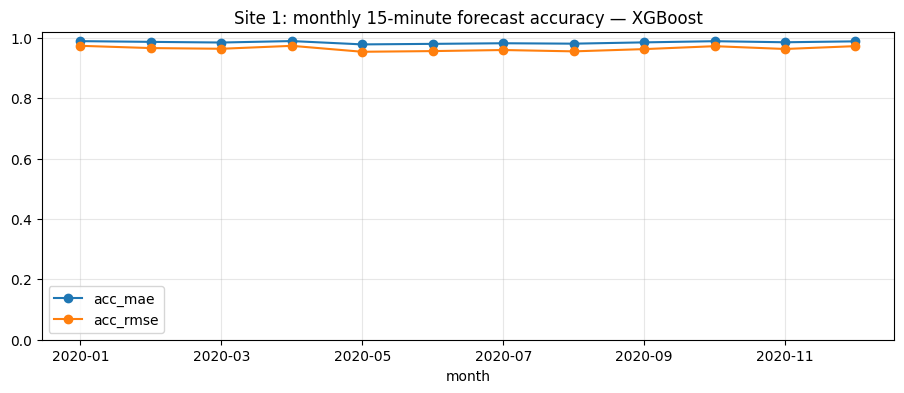

In [10]:
plot_df = xgb_monthly.copy()
plot_df["month"] = plot_df["month"].astype(str)
for site, station in plot_df.groupby("site"):
    ax = station.plot(x="month", y=["acc_mae", "acc_rmse"], marker="o", figsize=(11, 4))
    ax.set_title(f"Site {site}: monthly 15-minute forecast accuracy — XGBoost")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    plt.show()


## 6. Vanilla Transformer baseline

This section reuses `src.vanilla_transformer` without rewriting the model. Each sample contains the preceding 96 observations and predicts the next capacity factor. Scaling is fitted on training frames only. Windows never cross missing-target gaps or split boundaries.

If the active Jupyter kernel does not have PyTorch, install it into that kernel first (for example with `%pip install torch`) and restart the kernel.

In [11]:
try:
    import torch
except ImportError as exc:
    raise ImportError(
        "PyTorch is required only for the Transformer section. "
        "Run `%pip install torch` in this notebook kernel, restart, and rerun."
    ) from exc

# This env ships several OpenMP runtimes (torch, sklearn, skimage, cvxopt each
# bundle their own libomp/libgomp). Once sklearn/XGBoost above has loaded one,
# torch's threaded CPU kernels deadlock or segfault on the first parallel op —
# in practice the torch.sin inside the positional encoding below. Training runs
# on MPS, so pinning torch to a single CPU thread costs nothing and avoids it.
torch.set_num_threads(1)

from src.vanilla_transformer import (
    Standardizer, WindowDataset, make_dataloaders,
    TransformerForecaster, Trainer, pick_device,
)
if DEVICE == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError(
        "DEVICE='mps' was requested, but this Jupyter kernel cannot access MPS. "
        "Restart Jupyter from the native arm64 py310 environment and rerun."
    )
print("torch:", torch.__version__, "device:", DEVICE)
print("MPS available:", torch.backends.mps.is_available())
print("torch CPU threads:", torch.get_num_threads())


torch: 2.7.1 device: mps
MPS available: True
torch CPU threads: 1


In [12]:
tr_features = transformer_feature_columns(prepared)
frames = {
    split: make_contiguous_frames(
        prepared, split, tr_features, min_length=LOOKBACK + HORIZON
    )
    for split in ("train", "val", "test")
}
scaler = Standardizer.fit_frames(frames["train"], tr_features)
datasets = {
    split: WindowDataset.from_frames(
        frames[split], tr_features, target_col="cf",
        lookback=LOOKBACK, horizon=HORIZON, standardizer=scaler
    )
    for split in frames
}
device = DEVICE
loaders = make_dataloaders(
    datasets, batch_size=256, num_workers=0, seed=SEED, device=device
)
print("Transformer features:", tr_features)
print("window counts:", {k: len(v) for k, v in datasets.items()})


Transformer features: ['cf_input', 'irr_total', 'dni', 'ghi', 'temp', 'pressure', 'humidity', 'irr_total_missing', 'dni_missing', 'ghi_missing', 'temp_missing', 'pressure_missing', 'humidity_missing', 'tod_sin', 'tod_cos', 'doy_sin', 'doy_cos', 'site_1']
window counts: {'train': 26112, 'val': 8736, 'test': 35040}


In [13]:
torch.manual_seed(SEED)
transformer_model = TransformerForecaster(
    n_features=len(tr_features),
    context_length=LOOKBACK,
    horizon=HORIZON,
    d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.1,
)
transformer_trainer = Trainer(
    transformer_model, lr=1e-3, weight_decay=1e-4, device=device
)
transformer_history = transformer_trainer.fit(
    loaders["train"], loaders["val"],
    epochs=20, patience=5, verbose=True, show_progress=True
)


epoch 1/20 train:   0%|          | 0/102 [00:00<?, ?it/s]

epoch 1/20 val:   0%|          | 0/35 [00:00<?, ?it/s]

epoch  1 |   3.1s | train 0.02664 | val 0.00677  <- best


epoch 2/20 train:   0%|          | 0/102 [00:00<?, ?it/s]

epoch 2/20 val:   0%|          | 0/35 [00:00<?, ?it/s]

...

epoch 19/20 val:   0%|          | 0/35 [00:00<?, ?it/s]

epoch 19 |   2.7s | train 0.00187 | val 0.00105  <- best


epoch 20/20 train:   0%|          | 0/102 [00:00<?, ?it/s]

epoch 20/20 val:   0%|          | 0/35 [00:00<?, ?it/s]

epoch 20 |   2.7s | train 0.00180 | val 0.00136
best val loss: 0.00105


In [14]:
transformer_pred_cf, transformer_true_cf = transformer_trainer.predict(
    loaders["test"], return_targets=True, clip=(0, 1)
)
transformer_result = window_prediction_frame(
    frames["test"], datasets["test"], transformer_true_cf, transformer_pred_cf
)
transformer_result["y_true"] *= transformer_result["capacity"]
transformer_result["y_pred"] *= transformer_result["capacity"]
transformer_result["model"] = "vanilla_transformer"

transformer_monthly, transformer_site, transformer_overall = score_result(transformer_result)
display(transformer_monthly)
display(transformer_site)
print("overall mean monthly accuracy:", transformer_overall)


,site,month,n_15min,mae_mw,rmse_mw,acc_mae,acc_rmse
0,1,2020-01,2880.0,0.581956,1.277184,0.988361,0.974456
1,1,2020-02,2784.0,0.691655,1.640270,0.986167,0.967195
2,1,2020-03,2976.0,0.755434,1.584626,0.984891,0.968307
3,1,2020-04,2880.0,0.605873,1.376296,0.987883,0.972474
4,1,2020-05,2976.0,1.119004,2.225593,0.977620,0.955488
5,1,2020-06,2880.0,1.031489,2.176620,0.979370,0.956468
6,1,2020-07,2976.0,0.960163,2.039721,0.980797,0.959206
7,1,2020-08,2976.0,1.118051,2.382412,0.977639,0.952352
8,1,2020-09,2880.0,0.896398,1.918818,0.982072,0.961624
9,1,2020-10,2976.0,0.609329,1.306085,0.987813,0.973878


,site,mean_monthly_acc_mae,mean_monthly_acc_rmse
0,1,0.983691,0.964625


overall mean monthly accuracy: {'mean_monthly_acc_mae': 0.9836908945089743, 'mean_monthly_acc_rmse': 0.9646253974034279}


## 7. Final comparison

The Transformer loses the first `LOOKBACK` targets of each test block because it needs historical context. For a perfectly identical comparison set, merge model outputs on `(site, target_ts)` before rescoring. The cell below performs that inner join.

In [15]:
common_times = (
    xgb_result[["site", "target_ts"]]
    .merge(transformer_result[["site", "target_ts"]], on=["site", "target_ts"])
)
common_key = pd.MultiIndex.from_frame(common_times.drop_duplicates())

def on_common_targets(result):
    key = pd.MultiIndex.from_frame(result[["site", "target_ts"]])
    return result.loc[key.isin(common_key)].copy()

comparison_rows = []
for result in [persistence_result, xgb_result, transformer_result]:
    common = on_common_targets(result)
    monthly, _, overall = score_result(common)
    comparison_rows.append({"model": result["model"].iloc[0], **overall, "n_predictions": len(common)})

comparison = pd.DataFrame(comparison_rows).sort_values("mean_monthly_acc_rmse", ascending=False)
display(comparison)


,model,mean_monthly_acc_mae,mean_monthly_acc_rmse,n_predictions
2,vanilla_transformer,0.983691,0.964625,35040
1,xgboost,0.984622,0.964217,35040
0,persistence,0.978742,0.957102,35040


## Next steps

- Expand `SITES` after the single-site run succeeds.
- Keep the test period untouched while tuning on validation.
- For the fourth-hour task, use horizon 16 and evaluate only that horizon.
- For a full 15 min–4 h curve, train 16 direct XGBoost horizons or set the Transformer horizon to 16.
- Report the all-slot metric required here, and optionally add a daytime-only diagnostic because night zeros can make the all-slot score look optimistic.